# CFG (Classifier-Free Guidance) 演示

本notebook演示了Classifier-Free Guidance技术, 这是扩散模型中用于条件生成的重要技术。

## CFG 核心概念

CFG通过以下公式实现条件生成：
```
CFG预测 = (1 + w) * 条件预测 - w * 无条件预测
```

其中：
- `w` 是guidance scale, 控制条件的影响程度
- `w = 0`：等同于无条件生成
- `w > 0`：增强条件影响
- `w = 1`：标准条件生成
- `w > 1`：强条件生成

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 设置设备
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"使用设备: {device}")

使用设备: cuda


## 1. 定义条件生成模型

创建一个支持条件输入的扩散模型。

In [29]:
class ConditionalUNet(nn.Module):
    def __init__(self, input_dim=1, num_classes=3, hidden_dim=64):
        super().__init__()
        
        self.num_classes = num_classes
        
        # 类别嵌入
        self.class_embedding = nn.Embedding(num_classes, hidden_dim)
        
        # 时间嵌入
        self.time_embedding = nn.Sequential(
            nn.Linear(128, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        # 条件编码器
        self.encoder = nn.Sequential(
            nn.Conv1d(input_dim + hidden_dim * 2, hidden_dim, 3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim, hidden_dim * 2, 3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim * 2, hidden_dim * 2, 3, padding=1),
            nn.SiLU(),
        )
        
        # 解码器
        self.decoder = nn.Sequential(
            nn.Conv1d(hidden_dim * 2, hidden_dim * 2, 3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim * 2, hidden_dim, 3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim, input_dim, 3, padding=1)
        )
        
    def timestep_embedding(self, timesteps):
        """创建时间步嵌入"""
        half_dim = 64
        device = timesteps.device
        
        embeddings = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = timesteps[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=1)
        return embeddings
    
    def forward(self, x, t, class_labels=None):
        # 时间嵌入
        t_emb = self.timestep_embedding(t)
        t_emb = self.time_embedding(t_emb)
        
        # 类别嵌入
        if class_labels is not None:
            c_emb = self.class_embedding(class_labels)
        else:
            # 无条件时使用零向量
            batch_size = x.shape[0]
            c_emb = torch.zeros(batch_size, self.class_embedding.embedding_dim, device=x.device)
        
        # 扩展时间嵌入和类别嵌入
        while len(t_emb.shape) < len(x.shape):
            t_emb = t_emb.unsqueeze(-1)
            c_emb = c_emb.unsqueeze(-1)
        
        # 拼接输入、时间嵌入和类别嵌入
        x_with_cond = torch.cat([x, t_emb.expand(-1, -1, x.shape[-1]), c_emb.expand(-1, -1, x.shape[-1])], dim=1)
        
        # 编码-解码
        encoded = self.encoder(x_with_cond)
        decoded = self.decoder(encoded)
        
        return decoded

## 2. 定义噪声调度器和采样器

In [30]:
class NoiseScheduler:
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device='cpu'):
        self.num_timesteps = num_timesteps
        self.device = device
        
        # 线性调度
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        
        # 预计算常用值
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        
        # 后验方差
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
    
    def add_noise(self, original, noise, timestep):
        if hasattr(timestep, 'device') and timestep.device != self.device:
            timestep = timestep.to(self.device)
        
        sqrt_alpha_prod = self.sqrt_alphas_cumprod[timestep]
        sqrt_one_minus_alpha_prod = self.sqrt_one_minus_alphas_cumprod[timestep]
        
        while len(sqrt_alpha_prod.shape) < len(original.shape):
            sqrt_alpha_prod = sqrt_alpha_prod.unsqueeze(-1)
            sqrt_one_minus_alpha_prod = sqrt_one_minus_alpha_prod.unsqueeze(-1)
            
        return sqrt_alpha_prod * original + sqrt_one_minus_alpha_prod * noise
    
    def get_ddim_params(self, timestep, prev_timestep, eta=0.0):
        if hasattr(timestep, 'device') and timestep.device != self.device:
            timestep = timestep.to(self.device)
        if hasattr(prev_timestep, 'device') and prev_timestep.device != self.device:
            prev_timestep = prev_timestep.to(self.device)
            
        alpha_cumprod_t = self.alphas_cumprod[timestep]
        if prev_timestep >= 0:
            alpha_cumprod_prev = self.alphas_cumprod[prev_timestep]
        else:
            alpha_cumprod_prev = torch.tensor(1.0, device=self.device)
        
        sqrt_alpha_t = torch.sqrt(alpha_cumprod_t)
        sqrt_alpha_prev_t = torch.sqrt(alpha_cumprod_prev)
        sqrt_one_minus_alpha_t = torch.sqrt(1 - alpha_cumprod_t)
        sqrt_one_minus_alpha_prev_t = torch.sqrt(1 - alpha_cumprod_prev)
        
        return alpha_cumprod_t, alpha_cumprod_prev, sqrt_alpha_t, sqrt_alpha_prev_t, sqrt_one_minus_alpha_t, sqrt_one_minus_alpha_prev_t

In [31]:
class CFGSampler:
    def __init__(self, model, scheduler):
        self.model = model
        self.scheduler = scheduler
    
    @torch.no_grad()
    def sample(self, shape, class_labels=None, guidance_scale=1.0, num_inference_steps=50, eta=0.0, device='cpu'):
        """
        CFG采样
        - class_labels: 条件标签, None表示无条件生成
        - guidance_scale: CFG控制强度 (0=无条件, 1=标准条件, >1=强条件)
        """
        # 生成子序列的时间步
        step_ratio = self.scheduler.num_timesteps // num_inference_steps
        timesteps = torch.arange(
            self.scheduler.num_timesteps - 1, -1, -step_ratio, dtype=torch.long, device=device
        )[:num_inference_steps]
        
        # 从纯噪声开始
        x = torch.randn(shape, device=device)
        
        for i, t in enumerate(tqdm(timesteps, desc="CFG采样", leave=False)):
            # 创建输入批次：条件 + 无条件
            x_double = torch.cat([x, x], dim=0)
            t_double = t.clone().detach().expand(shape[0] * 2).to(device)
            
            # 创建标签批次：条件 + 无条件(-1表示无条件)
            if class_labels is not None:
                cond_labels = class_labels
                uncond_labels = torch.full_like(class_labels, -1)  # -1表示无条件
            else:
                cond_labels = torch.full((shape[0],), -1, device=device)
                uncond_labels = torch.full((shape[0],), -1, device=device)
            
            # 将负数标签映射到有效范围内(embedding会处理这种情况)
            if torch.any(cond_labels < 0):
                cond_labels = torch.zeros_like(cond_labels, dtype=torch.long)
            if torch.any(uncond_labels < 0):
                uncond_labels = torch.zeros_like(uncond_labels, dtype=torch.long)
            
            labels_double = torch.cat([cond_labels, uncond_labels], dim=0)
            
            # 预测噪声(条件和无条件)
            predicted_noise_double = self.model(x_double, t_double, labels_double)
            
            # 分离条件和无条件预测
            predicted_noise_cond = predicted_noise_double[:shape[0]]
            predicted_noise_uncond = predicted_noise_double[shape[0]:]
            
            # CFG组合
            if guidance_scale == 0:
                predicted_noise = predicted_noise_uncond
            elif guidance_scale == 1:
                predicted_noise = predicted_noise_cond
            else:
                predicted_noise = (1 + guidance_scale) * predicted_noise_cond - guidance_scale * predicted_noise_uncond
            
            # DDIM更新
            prev_t = timesteps[i + 1] if i < len(timesteps) - 1 else -1
            alpha_cumprod_t, alpha_cumprod_prev, sqrt_alpha_t, sqrt_alpha_prev_t, sqrt_one_minus_alpha_t, sqrt_one_minus_alpha_prev_t = self.scheduler.get_ddim_params(t, prev_t)
            
            # 预测的原始数据
            pred_original_sample = sqrt_alpha_prev_t * (x - sqrt_one_minus_alpha_t * predicted_noise) / sqrt_alpha_t
            
            # 方差项
            if eta > 0:
                variance = eta * torch.sqrt((1 - alpha_cumprod_prev) / (1 - alpha_cumprod_t)) * (1 - alpha_cumprod_t / alpha_cumprod_prev)
            else:
                variance = 0
            
            # 前向过程的均值方向
            prev_sample_direction = torch.sqrt(1 - alpha_cumprod_prev - variance**2) * predicted_noise
            
            # 更新x
            if eta > 0:
                noise = torch.randn_like(x)
                x = pred_original_sample + prev_sample_direction + variance * noise
            else:
                x = pred_original_sample + prev_sample_direction
        
        return x

## 3. 生成条件数据集

创建三种不同类型的信号：正弦波、三角波、方波。

训练数据形状: torch.Size([900, 1, 64])
标签形状: torch.Size([900])
类别分布: tensor([300, 300, 300])


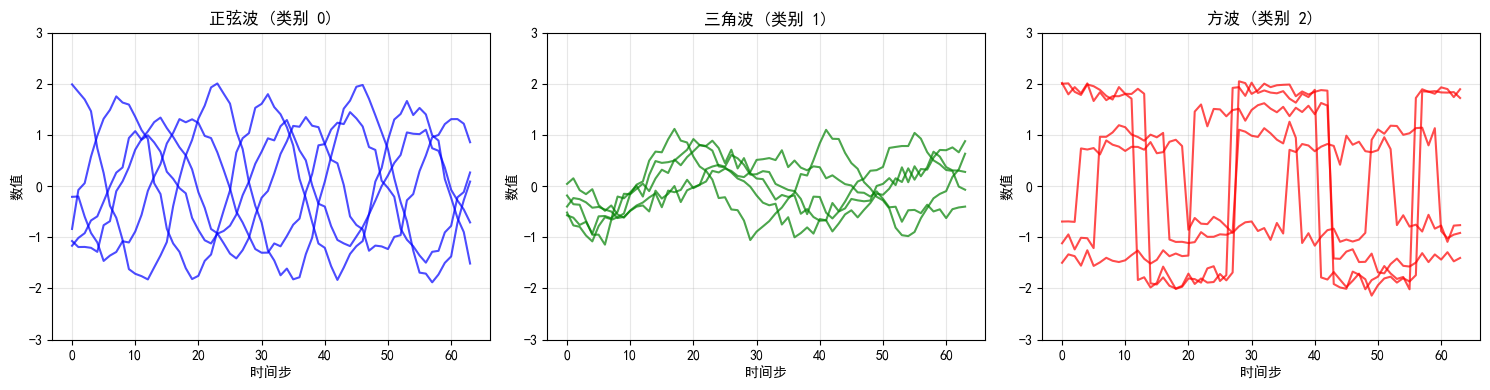

In [32]:
def generate_conditional_data(n_samples_per_class=500, seq_length=64):
    """生成条件数据集：正弦波、三角波、方波"""
    data = []
    labels = []
    
    for class_id in range(3):
        for i in range(n_samples_per_class):
            # 生成时间序列
            t = np.linspace(0, 2 * np.pi, seq_length)
            
            if class_id == 0:  # 正弦波
                amplitude = np.random.uniform(0.5, 2.0)
                frequency = np.random.uniform(1, 3)
                phase = np.random.uniform(0, 2 * np.pi)
                signal = amplitude * np.sin(frequency * t + phase)
                
            elif class_id == 1:  # 三角波
                amplitude = np.random.uniform(0.5, 2.0)
                frequency = np.random.uniform(1, 3)
                phase = np.random.uniform(0, 2 * np.pi)
                signal = amplitude * (2 * np.arcsin(np.sin(frequency * t + phase)) / np.pi)
                
            else:  # 方波
                amplitude = np.random.uniform(0.5, 2.0)
                frequency = np.random.uniform(1, 3)
                phase = np.random.uniform(0, 2 * np.pi)
                signal = amplitude * np.sign(np.sin(frequency * t + phase))
            
            # 添加少量噪声
            signal += np.random.normal(0, 0.1, seq_length)
            
            data.append(signal)
            labels.append(class_id)
    
    return (
        torch.tensor(data, dtype=torch.float32).unsqueeze(1),  # 添加channel维度
        torch.tensor(labels, dtype=torch.long)
    )

# 生成数据
train_data, train_labels = generate_conditional_data(n_samples_per_class=300, seq_length=64)
print(f"训练数据形状: {train_data.shape}")
print(f"标签形状: {train_labels.shape}")
print(f"类别分布: {torch.bincount(train_labels)}")

# 可视化每种类型的样本
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
class_names = ['正弦波', '三角波', '方波']
colors = ['blue', 'green', 'red']

for class_id in range(3):
    # 找到该类别的所有样本
    class_mask = train_labels == class_id
    class_samples = train_data[class_mask]
    
    # 绘制前5个样本
    for i in range(min(5, len(class_samples))):
        axes[class_id].plot(class_samples[i, 0].numpy(), alpha=0.7, color=colors[class_id])
    
    axes[class_id].set_title(f'{class_names[class_id]} (类别 {class_id})')
    axes[class_id].set_xlabel('时间步')
    axes[class_id].set_ylabel('数值')
    axes[class_id].grid(True, alpha=0.3)
    axes[class_id].set_ylim([-3, 3])

plt.tight_layout()
plt.show()

## 4. 训练函数

In [33]:
def train_conditional_diffusion(model, scheduler, dataloader, num_epochs=50, lr=1e-4, device='cpu', dropout_prob=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    model.train()
    for epoch in tqdm(range(num_epochs), desc="训练条件扩散模型"):
        epoch_losses = []
        
        for batch_data, batch_labels in dataloader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            
            # 随机选择时间步
            timesteps = torch.randint(0, scheduler.num_timesteps, (batch_data.shape[0],), device=device)
            
            # 生成噪声
            noise = torch.randn_like(batch_data)
            
            # 添加噪声到数据
            noisy_data = scheduler.add_noise(batch_data, noise, timesteps)
            
            # CFG训练：以dropout_prob的概率将标签置为无条件
            mask = torch.rand(batch_data.shape[0], device=device) < dropout_prob
            train_labels = batch_labels.clone()
            train_labels[mask] = -1  # -1表示无条件
            
            # 将负数标签映射到有效范围(模型会处理这种情况)
            train_labels = torch.clamp(train_labels, min=0)
            
            # 预测噪声
            predicted_noise = model(noisy_data, timesteps, train_labels)
            
            # 计算损失
            loss = F.mse_loss(predicted_noise, noise)
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        avg_loss = np.mean(epoch_losses)
        losses.append(avg_loss)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    
    return losses

## 5. 训练条件扩散模型

开始训练条件扩散模型...


训练条件扩散模型:   4%|▍         | 2/50 [00:00<00:03, 13.11it/s]

Epoch 0, Loss: 1.001596


训练条件扩散模型:  28%|██▊       | 14/50 [00:00<00:02, 15.40it/s]

Epoch 10, Loss: 0.243060


...

训练条件扩散模型:  68%|██████▊   | 34/50 [00:02<00:01, 15.10it/s]

Epoch 30, Loss: 0.165059


训练条件扩散模型:  88%|████████▊ | 44/50 [00:02<00:00, 15.61it/s]

Epoch 40, Loss: 0.163474


训练条件扩散模型: 100%|██████████| 50/50 [00:03<00:00, 15.35it/s]


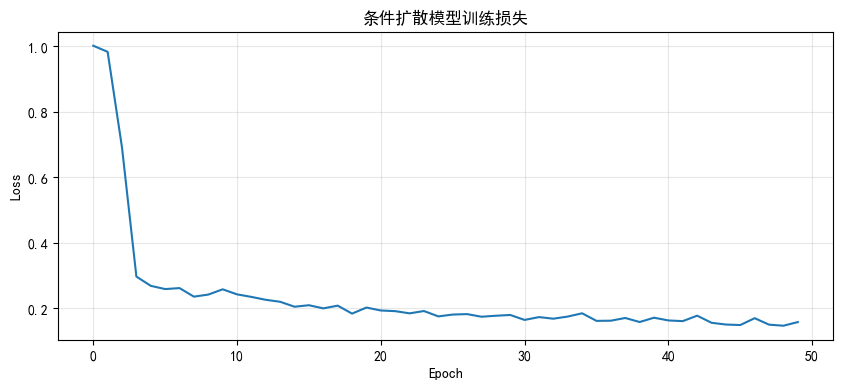

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
# 创建模型和调度器
num_classes = 3
scheduler = NoiseScheduler(num_timesteps=1000, device=device)
model = ConditionalUNet(input_dim=1, num_classes=num_classes, hidden_dim=64).to(device)

# 创建数据加载器
batch_size = 32
dataset = TensorDataset(train_data, train_labels)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 训练模型
print("开始训练条件扩散模型...")
losses = train_conditional_diffusion(model, scheduler, dataloader, num_epochs=50, lr=1e-4, device=device)

# 绘制损失曲线
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title('条件扩散模型训练损失')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

## 6. CFG效果演示

比较不同guidance scale下的生成效果。

In [35]:
# 创建CFG采样器
cfg_sampler = CFGSampler(model, scheduler)

# 生成样本
num_samples_per_class = 3
seq_length = 64
sample_shape = (num_samples_per_class, 1, seq_length)

# 不同的guidance scale值
guidance_scales = [0.0, 0.5, 1.0, 2.0, 5.0]
class_names = ['正弦波', '三角波', '方波']

# 为每个类别和每个guidance scale生成样本
all_samples = {}

for class_id in range(num_classes):
    all_samples[class_id] = {}
    class_labels = torch.full((num_samples_per_class,), class_id, dtype=torch.long, device=device)
    
    for guidance_scale in guidance_scales:
        print(f"生成 {class_names[class_id]} 样本, guidance_scale={guidance_scale}...")
        samples = cfg_sampler.sample(
            sample_shape, 
            class_labels=class_labels,
            guidance_scale=guidance_scale,
            num_inference_steps=50,
            eta=0.0,
            device=device
        )
        all_samples[class_id][guidance_scale] = samples.cpu()

print("样本生成完成！")

生成 正弦波 样本, guidance_scale=0.0...


生成 正弦波 样本, guidance_scale=0.5...


生成 正弦波 样本, guidance_scale=1.0...


生成 正弦波 样本, guidance_scale=2.0...


生成 正弦波 样本, guidance_scale=5.0...


...

生成 方波 样本, guidance_scale=0.5...


生成 方波 样本, guidance_scale=1.0...


生成 方波 样本, guidance_scale=2.0...


生成 方波 样本, guidance_scale=5.0...


样本生成完成！


## 7. 可视化CFG效果

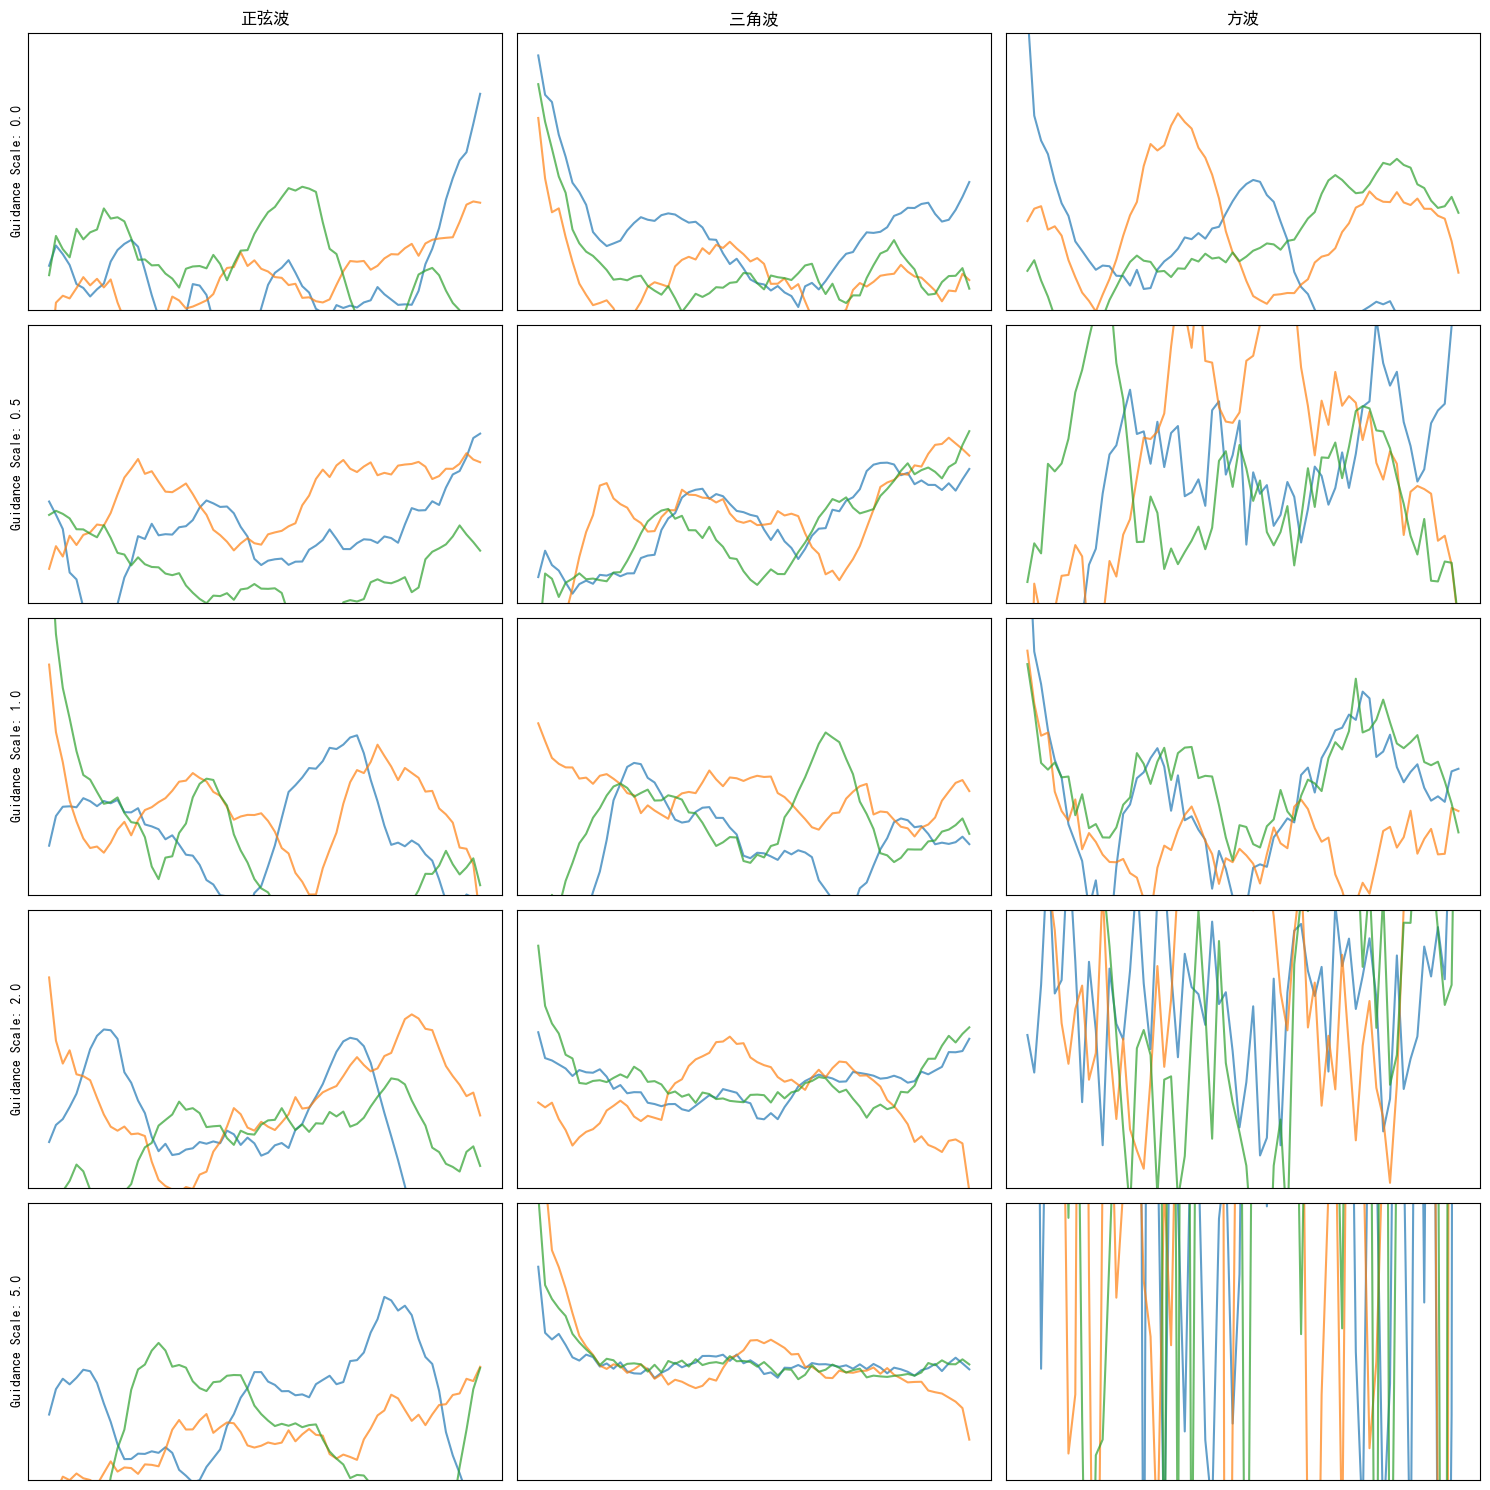

In [37]:
# 可视化不同guidance scale下的生成效果
fig, axes = plt.subplots(len(guidance_scales), num_classes, figsize=(15, 3*len(guidance_scales)))

for row, guidance_scale in enumerate(guidance_scales):
    for col, class_id in enumerate(range(num_classes)):
        ax = axes[row, col]
        
        # 绘制该guidance scale和类别的样本
        samples = all_samples[class_id][guidance_scale]
        for i in range(num_samples_per_class):
            ax.plot(samples[i, 0].numpy(), alpha=0.7)
        
        # 设置标题和标签
        if row == 0:
            ax.set_title(f'{class_names[class_id]}', fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'Guidance Scale: {guidance_scale}', fontsize=10)
        
        ax.set_ylim([-3, 3])
        ax.grid(True, alpha=0.3)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

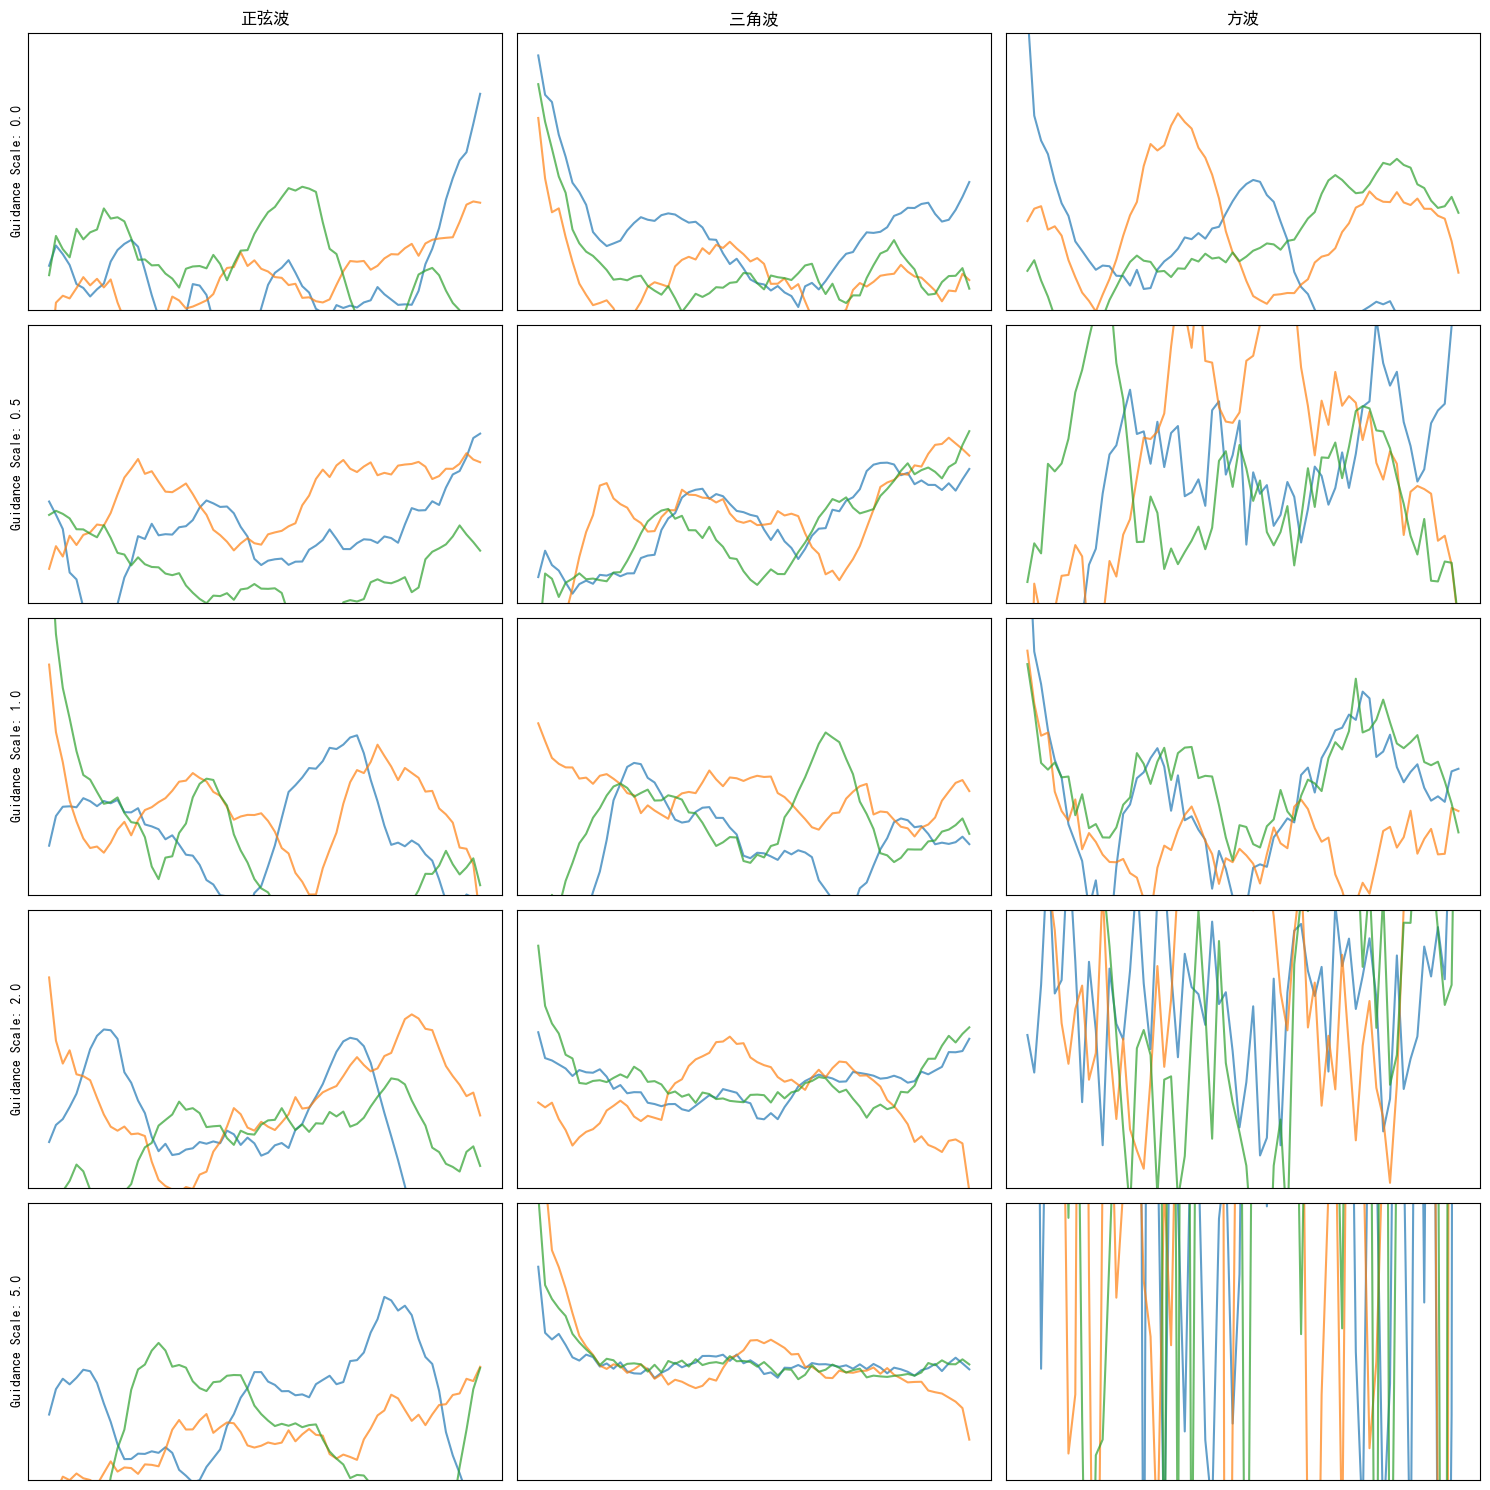

In [38]:
# 可视化不同guidance scale下的生成效果
fig, axes = plt.subplots(len(guidance_scales), num_classes, figsize=(15, 3*len(guidance_scales)))

for row, guidance_scale in enumerate(guidance_scales):
    for col, class_id in enumerate(range(num_classes)):  # 修复：使用range(num_classes)
        ax = axes[row, col]
        
        # 绘制该guidance scale和类别的样本
        samples = all_samples[class_id][guidance_scale]
        for i in range(num_samples_per_class):
            ax.plot(samples[i, 0].numpy(), alpha=0.7)
        
        # 设置标题和标签
        if row == 0:
            ax.set_title(f'{class_names[class_id]}', fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'Guidance Scale: {guidance_scale}', fontsize=10)
        
        ax.set_ylim([-3, 3])
        ax.grid(True, alpha=0.3)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

## 9. 连续Guidance Scale分析

分析guidance scale从0到5的连续变化效果。

生成连续guidance scale的样本...


100%|██████████| 11/11 [00:00<00:00, 16.58it/s]


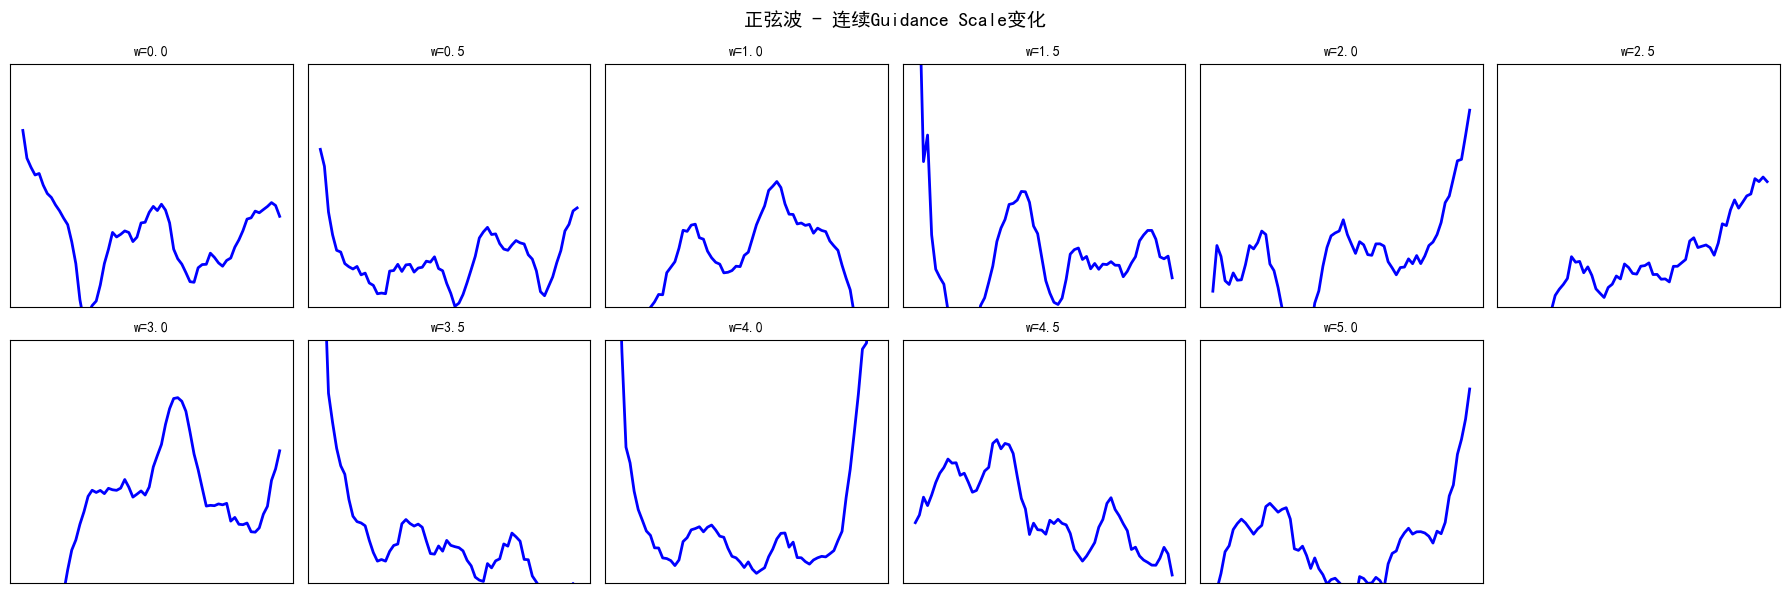

In [39]:
# 连续的guidance scale值
continuous_scales = np.linspace(0, 5, 11)
target_class = 0  # 正弦波
target_label = torch.tensor([target_class], dtype=torch.long, device=device)
target_shape = (1, 1, seq_length)

# 生成连续guidance scale的样本
continuous_samples = []

print("生成连续guidance scale的样本...")
for scale in tqdm(continuous_scales):
    sample = cfg_sampler.sample(
        target_shape,
        class_labels=target_label,
        guidance_scale=scale,
        num_inference_steps=50,
        eta=0.0,
        device=device
    )
    continuous_samples.append(sample.cpu())

# 可视化连续变化
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

for i, (scale, sample) in enumerate(zip(continuous_scales, continuous_samples)):
    axes[i].plot(sample[0, 0].numpy(), linewidth=2, color='blue')
    axes[i].set_title(f'w={scale:.1f}', fontsize=10)
    axes[i].set_ylim([-3, 3])
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

# 移除最后一个空的子图
axes[-1].set_visible(False)

plt.suptitle(f'{class_names[target_class]} - 连续Guidance Scale变化', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. CFG公式可视化

可视化CFG公式中条件和无条件预测的组合过程。

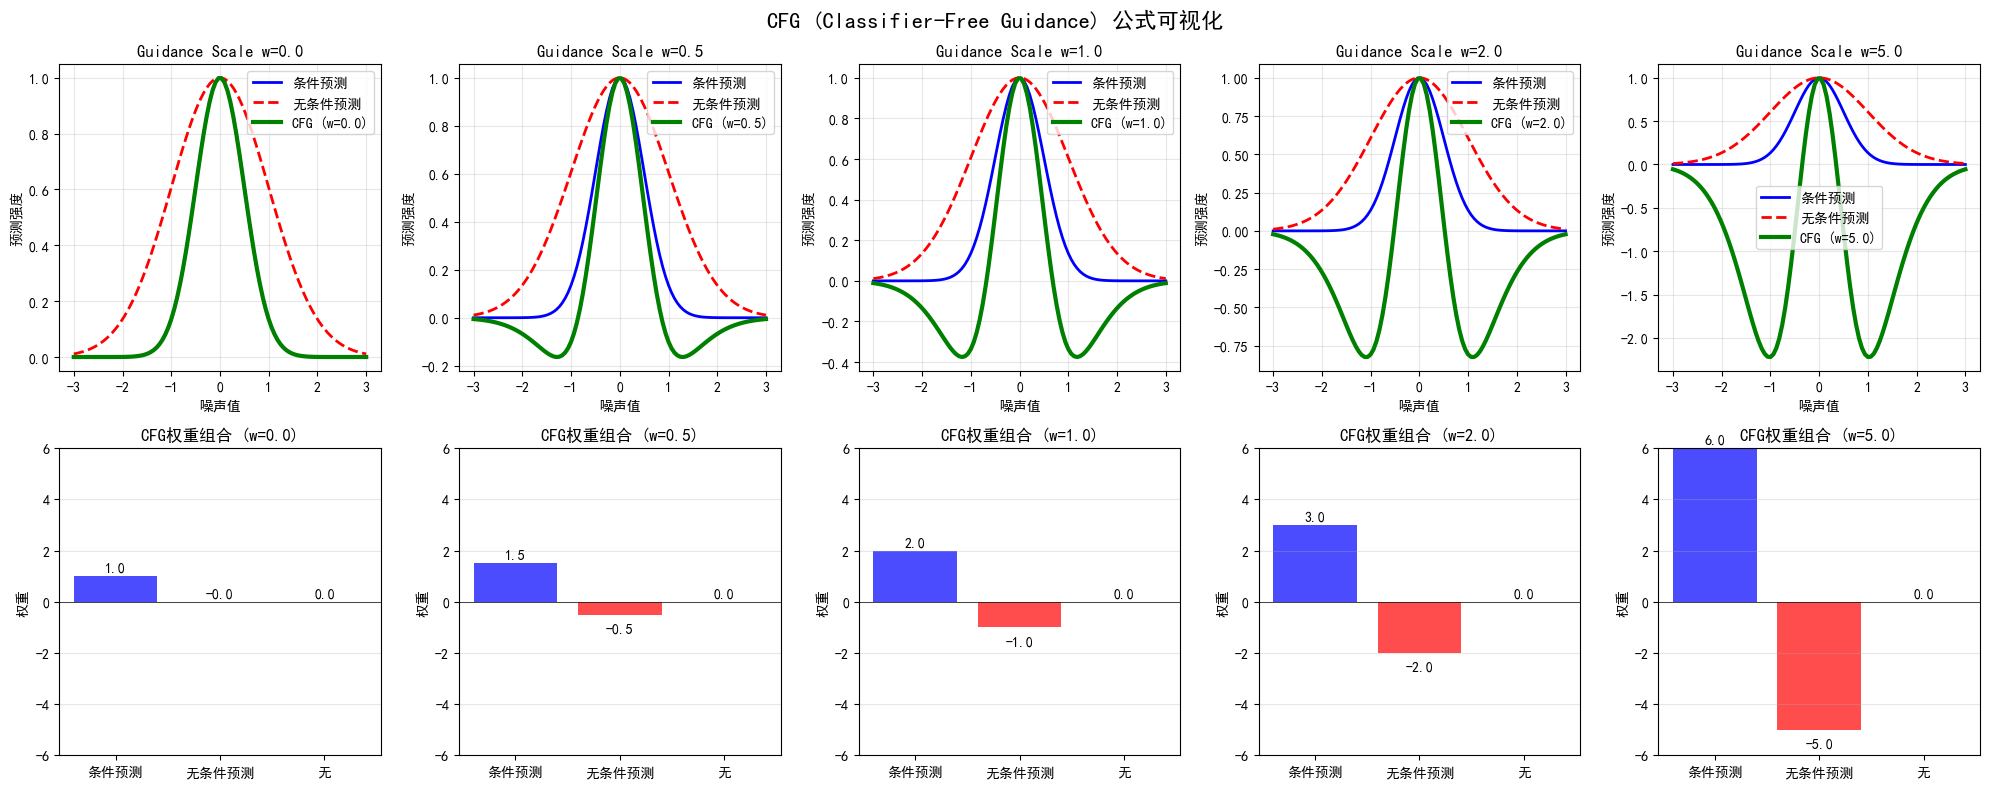


CFG公式说明:
预测 = (1 + w) × 条件预测 - w × 无条件预测

• w = 0: 完全无条件生成
• w = 1: 标准条件生成
• w > 1: 强条件生成, 增强条件影响
• w → ∞: 趋向于极端条件化


In [40]:
# 演示CFG公式的计算过程
def demonstrate_cfg_formula():
    """可视化CFG公式的组合过程"""
    guidance_scales_demo = [0.0, 0.5, 1.0, 2.0, 5.0]
    
    # 创建示例条件和无条件预测(简化为一维)
    x_points = torch.linspace(-3, 3, 100)
    
    # 模拟条件预测和无条件预测
    # 条件预测：更锐利的分布(表示更强的条件性)
    cond_pred = torch.exp(-x_points**2 / 0.5)  # 高斯分布, 方差较小
    # 无条件预测：更平缓的分布(表示更随机)
    uncond_pred = torch.exp(-x_points**2 / 2.0)  # 高斯分布, 方差较大
    
    fig, axes = plt.subplots(2, len(guidance_scales_demo), figsize=(20, 8))
    
    for i, w in enumerate(guidance_scales_demo):
        # 计算CFG组合
        cfg_pred = (1 + w) * cond_pred - w * uncond_pred
        
        # 上图：展示条件和无条件预测的组合
        axes[0, i].plot(x_points.numpy(), cond_pred.numpy(), 'b-', label='条件预测', linewidth=2)
        axes[0, i].plot(x_points.numpy(), uncond_pred.numpy(), 'r--', label='无条件预测', linewidth=2)
        axes[0, i].plot(x_points.numpy(), cfg_pred.numpy(), 'g-', label=f'CFG (w={w})', linewidth=3)
        axes[0, i].set_title(f'Guidance Scale w={w}', fontsize=12, fontweight='bold')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)
        axes[0, i].set_xlabel('噪声值')
        axes[0, i].set_ylabel('预测强度')
        
        # 下图：展示权重分布
        weights = [1 + w, -w, 0]  # 条件权重、无条件权重、常量项
        labels = ['条件预测', '无条件预测', '无']
        colors = ['blue', 'red', 'gray']
        
        bars = axes[1, i].bar(labels, weights, color=colors, alpha=0.7)
        axes[1, i].set_ylim([-6, 6])
        axes[1, i].set_title(f'CFG权重组合 (w={w})')
        axes[1, i].set_ylabel('权重')
        axes[1, i].grid(True, alpha=0.3, axis='y')
        axes[1, i].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        # 在柱状图上显示数值
        for bar, weight in zip(bars, weights):
            height = bar.get_height()
            axes[1, i].text(bar.get_x() + bar.get_width()/2., height + (0.1 if height >= 0 else -0.3),
                           f'{weight:.1f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=10)
    
    plt.suptitle('CFG (Classifier-Free Guidance) 公式可视化', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

demonstrate_cfg_formula()

print("\nCFG公式说明:")
print("预测 = (1 + w) × 条件预测 - w × 无条件预测")
print("")
print("• w = 0: 完全无条件生成")
print("• w = 1: 标准条件生成")
print("• w > 1: 强条件生成, 增强条件影响")
print("• w → ∞: 趋向于极端条件化")

## 11. 总结与结论

### CFG 技术要点：

1. **核心思想**：
   - 同时训练条件和无条件生成
   - 推理时将两种预测进行加权组合

2. **训练策略**：
   - 随机将条件标签替换为无条件(通常10-20%的概率)
   - 单一模型同时学习条件和无条件生成

3. **推理优势**：
   - 不需要额外的分类器
   - 可以动态调节条件强度
   - 兼容各种扩散模型架构

### Guidance Scale 的作用：

- **w = 0**：完全无条件, 生成随机样本
- **0 < w < 1**：弱条件化, 保持一定随机性
- **w = 1**：标准条件生成
- **1 < w < 3**：强条件化, 提高条件遵循度
- **w > 3**：极强条件化, 可能降低多样性

### 实际应用建议：

1. **文本到图像**：w = 7.5-15
2. **图像编辑**：w = 1-3
3. **风格迁移**：w = 2-5
4. **保持多样性**：w = 0.5-1.5

### 注意事项：

- 过高的guidance scale可能导致生成质量下降
- 不同任务需要调整最优的guidance scale
- CFG会增加计算开销(通常2倍)
- 训练时的dropout概率影响效果